Titanic Dataset Shape (rows, cols): (891, 12)

First Five Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123   

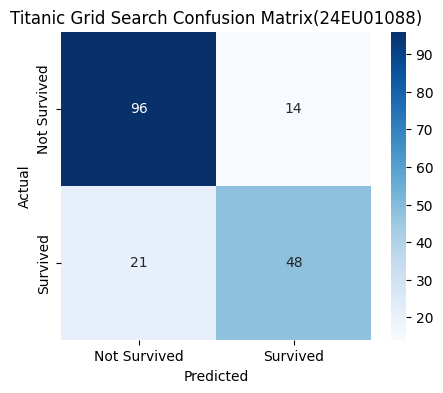

In [ ]:
# K-FOLD AND GRID SEARCH ON TITANIC DATASET

# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. LOAD TITANIC DATASET
# ============================================================

titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(titanic_url)

print("Titanic Dataset Shape (rows, cols):", titanic_df.shape)

print("\nFirst Five Rows:")
print(titanic_df.head())

print("\nMissing Values:")
print(titanic_df.isnull().sum())

# ============================================================
# 2. DATA PREPROCESSING AND TRAIN-TEST SPLIT
# ============================================================

# Select Features and Target
X_titanic = titanic_df[
    ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
].copy()

y_titanic = titanic_df['Survived']

# Handle missing Age values
X_titanic['Age'] = X_titanic['Age'].fillna(
    X_titanic['Age'].median()
)

# Encode Sex
label_encoder = LabelEncoder()
X_titanic['Sex'] = label_encoder.fit_transform(
    X_titanic['Sex']
)

# Train-Test Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

print("\nTitanic Training Set Shape:", X_train_t.shape)
print("Titanic Test Set Shape:", X_test_t.shape)

# ============================================================
# 3. K-FOLD CROSS-VALIDATION
# ============================================================

# Create Random Forest Classifier
rf_titanic = RandomForestClassifier(random_state=42)

# Create 10-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Calculate Cross-Validation Scores
cv_scores = cross_val_score(
    rf_titanic,
    X_titanic,
    y_titanic,
    cv=cv_strategy,
    scoring='accuracy'
)

print("\n========== K-FOLD CROSS-VALIDATION ==========")

print("10-Fold Stratified CV Accuracy Scores:")
print(cv_scores.round(4))

print(
    "\nMean Cross-Validation Accuracy: "
    f"{cv_scores.mean() * 100:.2f}%"
)

print(
    "Standard Deviation of CV Accuracy: "
    f"{cv_scores.std() * 100:.2f}%"
)

# ============================================================
# 4. GRID SEARCH
# ============================================================

# Define Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Create Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Perform Grid Search
grid_search.fit(X_train_t, y_train_t)

# Get Best Model
best_rf_grid = grid_search.best_estimator_

# Predict Test Data
grid_preds = best_rf_grid.predict(X_test_t)

# Calculate Test Accuracy
grid_accuracy = accuracy_score(
    y_test_t,
    grid_preds
)

print("\n========== GRID SEARCH ==========")

print("Optimal Hyperparameters:")
print(grid_search.best_params_)

print(
    "\nBest Grid Search CV Accuracy: "
    f"{grid_search.best_score_ * 100:.2f}%"
)

print(
    "\nGrid Search Optimized Test Accuracy: "
    f"{grid_accuracy * 100:.2f}%"
)

# ============================================================
# 5. K-FOLD AND GRID SEARCH COMPARISON
# ============================================================

results = pd.DataFrame({
    'Method': [
        '10-Fold Stratified Cross-Validation',
        'Grid Search Optimized Random Forest'
    ],
    'Accuracy (%)': [
        cv_scores.mean() * 100,
        grid_accuracy * 100
    ]
})

print("\n========== COMPARISON ==========")
print(results.to_string(index=False))

# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_t,
        grid_preds
    )
)

# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm_titanic = confusion_matrix(
    y_test_t,
    grid_preds
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_titanic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Titanic Grid Search Confusion Matrix(24EU01088)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()